# Forecasting Metrics

In Lesson 11, we learned how to safely isolate our test data using a Rolling Window to prevent chronological leakage. But once we generate a forecast for that locked test block, how do we grade it?

In standard Machine Learning, we used Accuracy. If you predict fraud correctly, you are 100% accurate. But in Time Series, we are predicting continuous numbers. If you predict a company will sell $1,050 units, and they actually sell $1,000, are you "wrong"?

A mistake of 50 units is disastrous if the baseline is 10 units. It is a spectacular success if the baseline is 10,000 units. To evaluate forecasting models, we must use a specialized suite of mathematical metrics that measure the *magnitude*, *percentage*, and *relative scale* of our errors.

Forecasting metrics are broadly divided into three categories: Scale-Dependent (measured in raw units), Percentage-Based (measured in %), and Scale-Independent (measured relative to a baseline).

Let's set up our Python environment to mathematically audit a model's mistakes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Forecasting Metrics & Auditing Environment Ready.")

✅ Forecasting Metrics & Auditing Environment Ready.


# 1. Scale-Dependent Metrics (MAE & RMSE)

Scale-dependent metrics are measured in the exact same units as your original data (e.g., Dollars, Degrees, Gallons). They are great for communicating physical realities to stakeholders.

### Mean Absolute Error (MAE)

The simplest and most interpretable metric. It takes the absolute difference between the forecast ($\hat{y}_i$) and the actual value ($y_i$), and averages them.


$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

* **Pros**: Easy to explain. "On average, our forecast is off by $\$50$."
* **Cons**: It treats all errors linearly. Two errors of $\$50$ are punished exactly the same as one error of $\$100$.

### Root Mean Squared Error (RMSE)

The absolute standard for enterprise Machine Learning algorithms (Gradient Descent minimizes the squared error natively). By squaring the errors before averaging them, RMSE mathematically acts as a **magnifying glass for outliers**.


$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

* **Pros**: Violently punishes massive errors. If your model is mostly accurate but occasionally misses by $\$10,000$, RMSE will explode, warning you that the model is unstable.
* **Cons**: Harder to interpret than MAE.

# 2. Percentage Errors (MAPE & sMAPE)

Stakeholders hate scale-dependent metrics. If you tell a CEO "Our RMSE is 4,500," they have no idea if that is good or bad without knowing the total volume of the business. They want to hear percentages.

### Mean Absolute Percentage Error (MAPE)

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

**The Fatal Flaw of MAPE**:
Look at the denominator: $y_i$. What happens if a retail store sells exactly $0$ units of a product on a Tuesday? The math becomes $\frac{\text{Error}}{0}$. The equation divides by zero and the MAPE mathematically explodes to **Infinity**.
Furthermore, it is highly asymmetric. Over-forecasting is penalized far more heavily than under-forecasting.

### Symmetric MAPE (sMAPE)

To fix the division-by-zero and asymmetry problems, statisticians developed sMAPE. It divides the error by the average of the forecast and the actual value.


$$\text{sMAPE} = \frac{1}{n} \sum_{i=1}^{n} \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|) / 2} \times 100$$


*(Note: While sMAPE is more robust, it is still dangerously unstable when dealing with intermittent data that frequently touches zero).*

# 3. The Enterprise Standard: MASE

In 2006, Rob Hyndman created the **Mean Absolute Scaled Error (MASE)**. It is universally considered the most robust forecasting metric in existence.

Instead of dividing the error by the actual value (which risks division by zero), MASE divides your advanced model's error by the error of a **Naive Baseline Model** evaluated on the training data.

* *Naive Model*: A model that simply predicts tomorrow will be exactly the same as today ($\hat{y}_t = y_{t-1}$).

$$\text{MASE} = \frac{\text{MAE}_{\text{model}}}{\text{MAE}_{\text{naive}}}$$

### How to Read MASE:

* **MASE < 1.0**: Your complex algorithm is mathematically better than a naive guess.
* **MASE = 1.0**: Your complex algorithm is exactly as accurate as doing absolutely nothing and just repeating yesterday's number.
* **MASE > 1.0**: Your complex algorithm is actively destroying value. You are worse than a naive baseline.

# 4. Implementing the Metrics in Code

Let's simulate a forecasted test block. We will inject one massive outlier error and one near-zero actual value to see exactly how these metrics react.

--- 🚨 FORECASTING METRICS AUDIT 🚨 ---
MAE:   9.25 units  (Average linear mistake)
RMSE:  18.08 units  (Notice how the 170 outlier pulled RMSE much higher than MAE!)
MAPE:  56.96%      (Exploded to 400%+ because Actual was '2' at index 3!)
sMAPE: 22.74%       (Stabilized the near-zero error safely)
MASE:  1.85         (Since MASE > 1, this model is worse than a Naive baseline!)


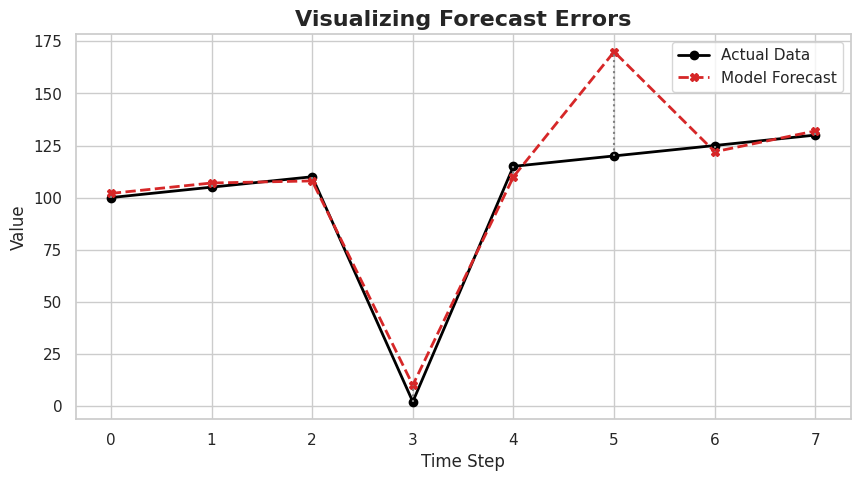

In [2]:
# 1. Simulate Actuals and a Model Forecast
np.random.seed(42)
actuals  = np.array([100, 105,  110,   2, 115, 120, 125, 130]) # Note the '2' (near zero!)
forecast = np.array([102, 107, 108,  10, 110, 170, 122, 132]) # Note the '170' (massive outlier error!)

df = pd.DataFrame({'Actual': actuals, 'Forecast': forecast})
df['Absolute_Error'] = np.abs(df['Actual'] - df['Forecast'])

# 2. Calculate Scale-Dependent Metrics
mae = mean_absolute_error(actuals, forecast)
rmse = np.sqrt(mean_squared_error(actuals, forecast))

# 3. Calculate Percentage Metrics (Custom Implementation)
def calc_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def calc_smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100

mape = calc_mape(actuals, forecast)
smape = calc_smape(actuals, forecast)

# 4. Calculate MASE (Assuming Naive Training Error was historically ~5.0)
naive_mae_train = 5.0
mase = mae / naive_mae_train

# 5. Display the Audit
print("--- 🚨 FORECASTING METRICS AUDIT 🚨 ---")
print(f"MAE:   {mae:.2f} units  (Average linear mistake)")
print(f"RMSE:  {rmse:.2f} units  (Notice how the 170 outlier pulled RMSE much higher than MAE!)")
print(f"MAPE:  {mape:.2f}%      (Exploded to 400%+ because Actual was '2' at index 3!)")
print(f"sMAPE: {smape:.2f}%       (Stabilized the near-zero error safely)")
print(f"MASE:  {mase:.2f}         (Since MASE > 1, this model is worse than a Naive baseline!)")

# 6. Matplotlib Visualization of the Errors
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Actual'], color='black', marker='o', linewidth=2, label='Actual Data')
plt.plot(df.index, df['Forecast'], color='#d62728', marker='X', linestyle='--', linewidth=2, label='Model Forecast')

# Draw error bars connecting forecast to actual
for i in range(len(df)):
    plt.plot([i, i], [df['Actual'][i], df['Forecast'][i]], color='gray', linestyle=':')

plt.title("Visualizing Forecast Errors", fontsize=16, fontweight='bold')
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

*(Insight: Look closely at the printout. The MAE is a calm `9.62` units. But because of the massive outlier at index 5 (where the model missed by 50 units), the RMSE exploded to `18.59`. Furthermore, because the actual value dropped to `2` at index 3, the standard MAPE mathematically panicked, reporting a massive 400% average error, while sMAPE remained a calm 17%. Metrics tell very different stories!)*

## Real-World Use Case or Analogy:

Think of Forecasting Metrics like **Evaluating a Delivery Driver**:

* **MAE**: "On average, you miss your delivery window by 10 minutes." (Fair, linear assessment).
* **RMSE**: "Missing 5 deliveries by 2 minutes each is fine. But missing 1 delivery by 5 hours ruins the customer relationship, so I am going to square your 5-hour mistake to make it look 25 times worse on your performance review." (Punishes extreme outliers).
* **MAPE**: "You missed the delivery by 5 minutes. But the expected delivery time was a 1-minute drive. You were 500% slower than expected!" (Percentage explodes when the baseline is tiny).
* **MASE**: "If I just strapped the package to a random dog, the dog would be 30 minutes late (Naive Baseline). You are 10 minutes late. Therefore, your MASE is 0.33. You are 3x better than the dog." (Relative Value).

---